In [1]:
# 1. IMPORT LIBRARIES 
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import io
from scipy.fftpack import dct, idct

In [2]:
#  2. LOAD AND DISPLAY IMAGE 
img_url = 'https://upload.wikimedia.org/wikipedia/en/7/7d/Lenna_%28test_image%29.png'
img = io.imread(img_url)

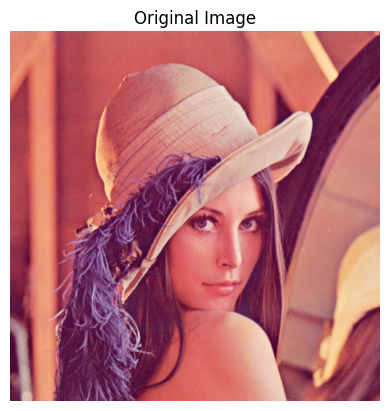

In [4]:
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')
plt.show()

In [6]:
# 3. CONVERT RGB TO YCbCr 
img_ycbcr = cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb)

In [7]:
Y, Cr, Cb = cv2.split(img_ycbcr)

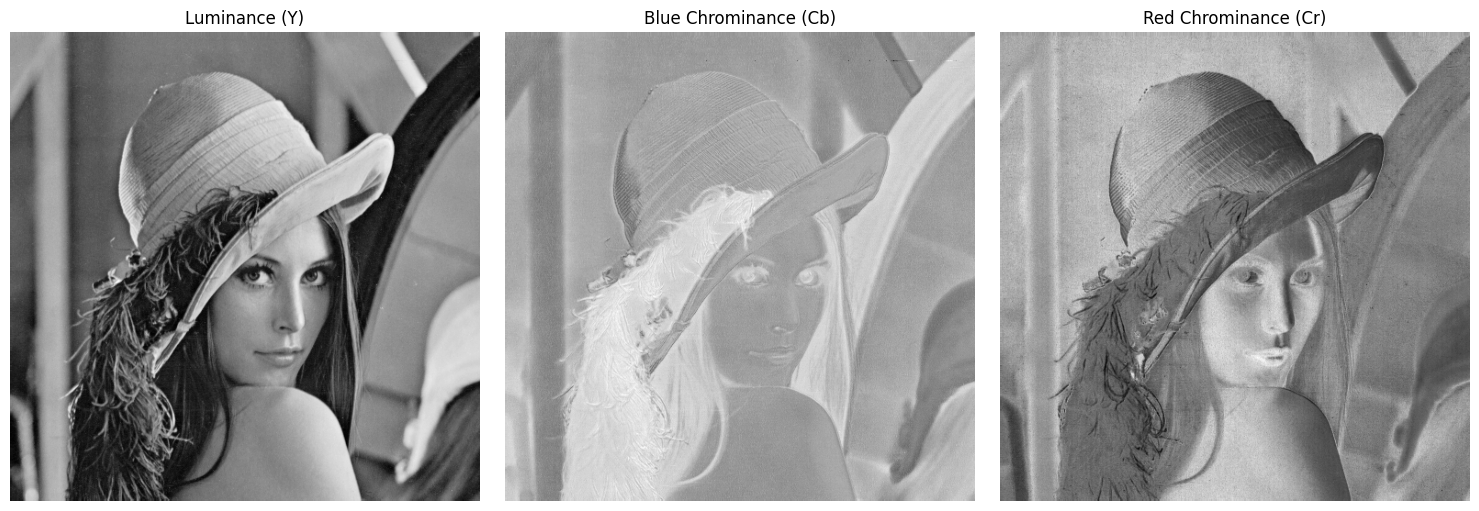

In [ ]:
# Visualize channels
plt.figure(figsize=(12, 4))
for i, (channel, title) in enumerate(zip([Y, Cb, Cr], ["Y (Luminance)", "Cb (Blue Chrominance)", "Cr (Red Chrominance)"])):
    plt.subplot(1, 3, i+1)
    plt.imshow(channel, cmap='gray')
    plt.title(title)
    plt.axis('off')
plt.show()

In [ ]:
def chroma_subsample(channel):
    h, w = channel.shape
    h, w = h - h % 2, w - w % 2

    channel = channel[:h, :w]

    subsampled = np.zeros((h // 2, w // 2), dtype=np.float32)

    for i in range(0, h, 2):
        for j in range(0, w, 2):
            top_left     = channel[i, j]
            top_right    = channel[i, j+1]
            bottom_left  = channel[i+1, j]
            bottom_right = channel[i+1, j+1]

            average = (top_left + top_right + bottom_left + bottom_right) / 4

            subsampled[i//2, j//2] = average

    return subsampled.astype(np.uint8)

In [ ]:
Cb_sub = chroma_subsample(Cb)
Cr_sub = chroma_subsample(Cr)

C:\Users\User\AppData\Local\Temp\ipykernel_7804\3996481748.py:16: RuntimeWarning: overflow encountered in scalar add
  average = (top_left + top_right + bottom_left + bottom_right) / 4


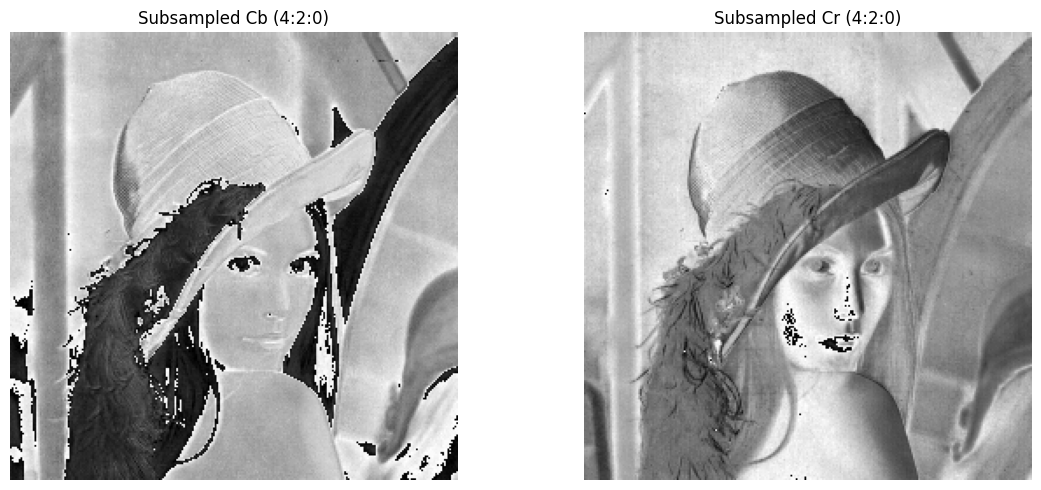

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(Cb_sub, cmap='gray')
axes[0].set_title('Subsampled Cb (4:2:0)')
axes[0].axis('off')

axes[1].imshow(Cr_sub, cmap='gray')
axes[1].set_title('Subsampled Cr (4:2:0)')
axes[1].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
def split_into_blocks(channel, block_size=8):
    h, w = channel.shape
    h_trim = h - (h % block_size)
    w_trim = w - (w % block_size)
    channel = channel[:h_trim, :w_trim]

    blocks = []
    for i in range(0, h_trim, block_size):
        row_blocks = []
        for j in range(0, w_trim, block_size):
            block = channel[i:i+block_size, j:j+block_size]
            row_blocks.append(block)
        blocks.append(row_blocks)

    return np.array(blocks)

In [ ]:
blocks = split_into_blocks(Y, 8)

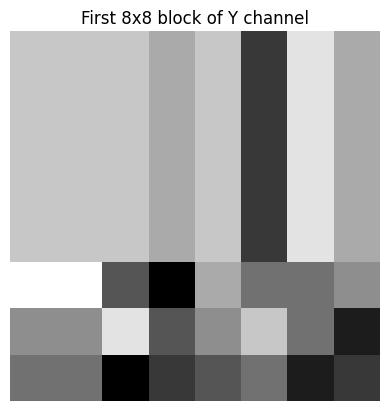

In [ ]:
plt.imshow(blocks[0, 0], cmap='gray')
plt.title('First 8x8 block of Y channel')
plt.axis('off')
plt.show()

In [ ]:
def dct2D(block):
     return dct(dct(block.T, norm='ortho').T, norm='ortho')

In [ ]:
block_8x8 = blocks[0, 0].astype(np.float32)

dct_block = dct2D(block_8x8)

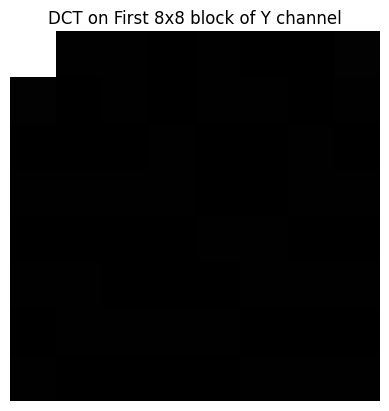

In [ ]:
plt.imshow(dct_block, cmap='gray')
plt.title('DCT on First 8x8 block of Y channel')
plt.axis('off')
plt.show()

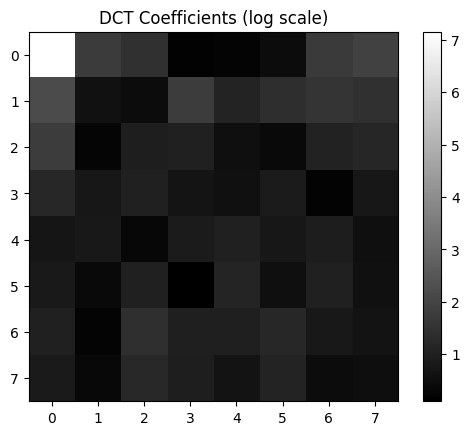

In [ ]:
plt.imshow(np.log(np.abs(dct_block) + 1), cmap='gray')
plt.title('DCT Coefficients (log scale)')
plt.colorbar()
plt.show()

In [ ]:
Q = np.array([[16, 11, 10, 16, 24, 40, 51, 61],
            [12, 12, 14, 19, 26, 58, 60, 55],
            [14, 13, 16, 24, 40, 57, 69, 56],
            [14, 17, 22, 29, 51, 87, 80, 62],
            [18, 22, 37, 56, 68, 109, 103, 77],
            [24, 35, 55, 64, 81, 104, 113, 92],
            [49, 64, 78, 87, 103, 121, 120, 101],
            [72, 92, 95, 98, 112, 100, 103, 99]])

quantized_block = dct_block/Q

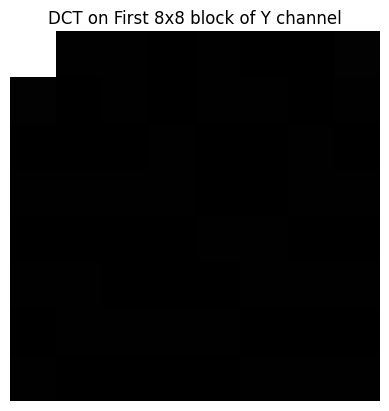

In [ ]:
plt.imshow(dct_block, cmap='gray')
plt.title('DCT on First 8x8 block of Y channel')
plt.axis('off')
plt.show()

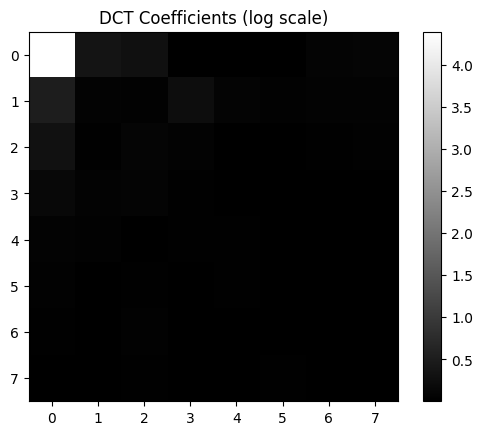

In [ ]:
plt.imshow(np.log(np.abs(quantized_block) + 1), cmap='gray')
plt.title('DCT Coefficients (log scale)')
plt.colorbar()
plt.show()

In [ ]:
dequantized_block = quantized_block * Q

In [ ]:
reconstructed_image = idct(idct(dequantized_block.T, norm ='ortho').T, norm = 'ortho') +128

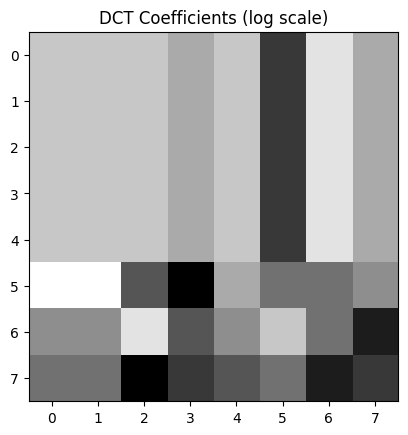

In [ ]:
plt.imshow(reconstructed_image, cmap='gray')
plt.title('DCT Coefficients (log scale)')
plt.show()

In [ ]:
def calculate_psnr(img1, img2):
    mse = np.mean((img1.astype(np.float32) - img2.astype(np.float32)) ** 2)
    if mse == 0:
        return float('inf')
    max_pixel = 255.0
    psnr = 10 * np.log10((max_pixel ** 2) / mse)
    return psnr

In [ ]:
psnr = calculate_psnr(blocks[0,0], reconstructed_image)

In [ ]:
print(f"The psnr value is: {psnr} dB")

The psnr value is: 5.9866042137146 dB
